In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import torchvision.datasets as datasets
from sklearn.metrics import precision_score

In [2]:
mnist_train = datasets.MNIST(root="./data", train=True, download=True)
mnist_test = datasets.MNIST(root="./data", train=False, download=True)

X_train = mnist_train.data.float() / 255.0 # normalize between 0 and 1
y_train = mnist_train.targets.long()
X_test = mnist_test.data.float() / 255.0
y_test = mnist_test.targets.long()

In [3]:
# Convert into pytorch tensors
train_ds = TensorDataset(X_train, y_train)
test_ds = TensorDataset(X_test, y_test)

batch_size = 32
train_dl = DataLoader(train_ds, batch_size=batch_size, shuffle=True, drop_last=True)
test_dl = DataLoader(test_ds, batch_size=test_ds.tensors[0].shape[0], shuffle=False)

In [4]:
class MNIST_Sequential(nn.Module):
    def __init__(self, n_units, n_layers):
        super().__init__()
        
        layers = []
        
        # Hidden Layers
        for i in range(n_layers):
            if i==0:
                layers.append(nn.Linear(28 * 28, n_units)) # first hidden layer
            else:
                layers.append(nn.Linear(n_units, n_units))
            layers.append(nn.ReLU())
            
        # Output Layer
        layers.append(nn.Linear(n_units, 10))
        
        # Unpack the list into Sequential
        self.model = nn.Sequential(*layers)

    def forward(self, x):
        x = torch.flatten(x, start_dim=1)
        # No loop needed here! Sequential handles the flow.
        return self.model(x)

def train_one_epoch(model, train_dl, optimizer, loss_fn):
    model.train()
    batch_acc = []
    batch_loss = []
    for X_batch, y_batch in train_dl:
        output = model(X_batch)
        loss = loss_fn(output, y_batch)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        batch_acc_item = (output.argmax(dim=1) == y_batch).float().mean().item()
        batch_acc.append(batch_acc_item)
        batch_loss.append(loss.item())
        
    return np.mean(batch_acc), np.mean(batch_loss)

def train_model(model, train_dl, test_dl, optimizer, loss_fn, epochs):
    
    train_acc = np.zeros(epochs)
    test_acc = np.zeros(epochs)
    losses = np.zeros(epochs)
    
    for epoch in range(epochs):
        train_acc[epoch], losses[epoch] = train_one_epoch(model, train_dl, optimizer, loss_fn)
        
        model.eval()
        with torch.no_grad():
            for X_batch, y_batch in test_dl:
                output = model(X_batch)
                test_acc[epoch] = (output.argmax(dim=1) == y_batch).float().mean().item()
                
    return train_acc, test_acc, losses

In [5]:
# 1 example
learning_rate = 0.01
epochs = 20
n_layers = 1
n_units = 4

model = MNIST_Sequential(n_units, n_layers)
optimzier = torch.optim.SGD(model.parameters(), lr=learning_rate)
loss_fn = nn.CrossEntropyLoss()
train_acc, test_acc, losses = train_model(model, train_dl, test_dl, optimzier, loss_fn, epochs)

In [ ]:
# New metrics, in this case we try precision but we can also use recall_score, f1_score, etc

# precision in this case can be measure on 1 single category
precision_score(y_test[y_test==3], model(X_test)[y_test==3].argmax(dim=1), average=None)

# or averaged=macro to give equal weight to each category regardless of the number of samples
precision_macro = precision_score(y_test, model(X_test).argmax(dim=1), average="macro")

# average precision weighted by the number of samples in each category
precision_weighted = precision_score(y_test, model(X_test).argmax(dim=1), average="weighted")

precision_macro, precision_weighted

(0.8495068713327321, 0.8510213949228688)

In [22]:
# Experiment
learning_rate = 0.01
epochs = 60
num_layers = range(1, 4)
num_units = range(50, 251, 50)

overall_test_accuracies = np.zeros((len(num_units), len(num_layers)))
overall_train_accuracies = np.zeros((len(num_units), len(num_layers)))

# IMPORTANT: the loss fun can be reused for multiple models, it doesnt store any state,
# but the optimizer needs to be redefined for each model since it stores the state of the parameters
loss_fn = nn.CrossEntropyLoss() # CrossEntropyLoss combines nn.LogSoftmax() and nn.NLLLoss()

for i, n_units in enumerate(num_units):
    for j, n_layers in enumerate(num_layers):
        print(f"Training model with {n_units} units and {n_layers} hidden layers...")
        model = MNIST_Sequential(n_units, n_layers)
        optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)  
        train_acc, test_acc, losses = train_model(model, train_dl, test_dl, optimizer, loss_fn, epochs)
        overall_train_accuracies[i, j] = np.mean(train_acc[-5:])  # Average of the last 5 epochs' train accuracy
        overall_test_accuracies[i, j] = np.mean(test_acc[-5:])  # Average of the last 5 epochs' test accuracy

Training model with 50 units and 1 hidden layers...
Training model with 50 units and 2 hidden layers...
Training model with 50 units and 3 hidden layers...
Training model with 100 units and 1 hidden layers...
Training model with 100 units and 2 hidden layers...
Training model with 100 units and 3 hidden layers...
Training model with 150 units and 1 hidden layers...
Training model with 150 units and 2 hidden layers...
Training model with 150 units and 3 hidden layers...
Training model with 200 units and 1 hidden layers...
Training model with 200 units and 2 hidden layers...
Training model with 200 units and 3 hidden layers...
Training model with 250 units and 1 hidden layers...
Training model with 250 units and 2 hidden layers...
Training model with 250 units and 3 hidden layers...


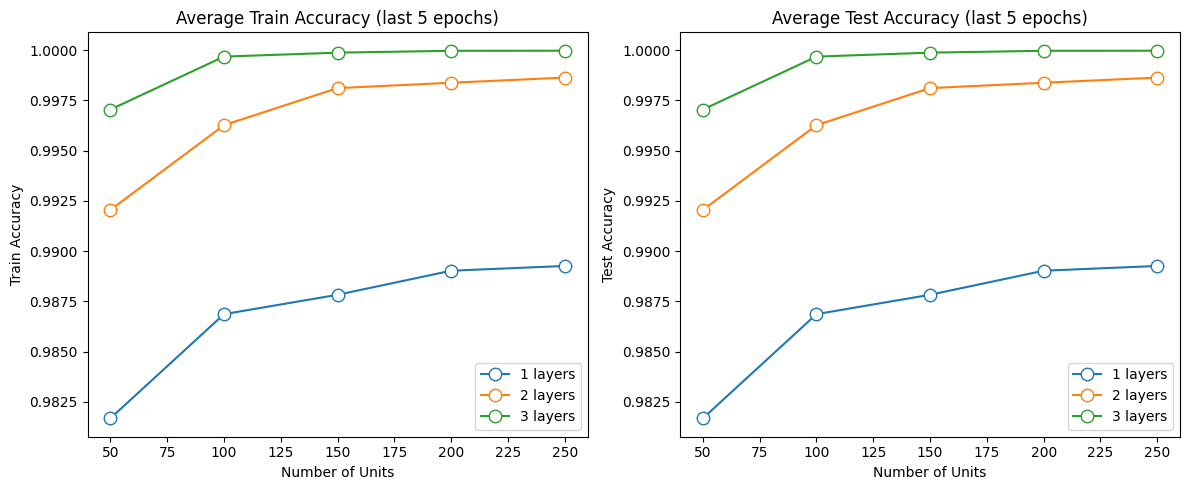

In [23]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ax[0].plot(num_units, overall_train_accuracies, "o-", markerfacecolor="w", markersize=9)
ax[0].legend([f"{n} layers" for n in num_layers])
ax[0].set_title("Average Train Accuracy (last 5 epochs)")
ax[0].set_xlabel("Number of Units")
ax[0].set_ylabel("Train Accuracy")

ax[1].plot(num_units, overall_train_accuracies, "o-", markerfacecolor="w", markersize=9)
ax[1].legend([f"{n} layers" for n in num_layers])
ax[1].set_title("Average Test Accuracy (last 5 epochs)")
ax[1].set_xlabel("Number of Units")
ax[1].set_ylabel("Test Accuracy")

plt.tight_layout()
plt.show()

# More complex problems generally do better with deeper networks, since deep networks can form more abstract
# representations. For iris data for example, increasing the number of layers was worsening the performance
# since it was a simpler problem. Not all the conclusions are the same for all datasets